# Which roofs get sun?

Monty lays out a procedural city; three.js builds it and casts a ray from every roof toward the
sun to measure the shadows.

* **Python, in Monty** (pydantic's Python sandbox) does the layout: hash-based zoning of a block
  grid into parks, low-rise and towers, lots with setbacks, heights drawn from a distribution,
  roads left between the blocks. It returns plain footprint rectangles and heights.
* **JavaScript, in pydeno** (a worker process behind an OS sandbox) does the 3D and the sun:
  three.js extrudes every building, adds a ground plane, then casts a `Raycaster` from a grid of
  sample points on each roof toward the sun. A point that reaches the sky is lit; the fraction of
  lit points is the building's score. Buildings are vertex-coloured by it (dark to bright), the
  result is ranked, and the scene is exported as a binary glTF (`.glb`).

Both halves run without trusting either: neither can touch your files, network or environment.
The only things they can call are the host functions the host hands them.

```
pip install pydeno pydantic-monty
```


In [1]:
from __future__ import annotations

import asyncio
import pathlib
import time
from typing import Any

from pydeno import WEB_POLYFILLS, IsolatedRuntime, RuntimeConfig
from pydantic_monty import Monty

# Jupyter's kernel already runs an asyncio event loop, so CityPipeline.render()'s
# `asyncio.run(...)` (verbatim from the script) would otherwise raise
# "cannot be called from a running event loop". nest_asyncio patches that loop to
# allow nesting -- the only deviation from the script, needed for notebook execution only.
import nest_asyncio

nest_asyncio.apply()

Paths and constants. Run from the repo root, so the vendored three.js bundle resolves the same way the script finds it relative to its own file.

In [2]:
def _repo_root() -> pathlib.Path:
    """Walk up from the current directory to find the pydeno checkout: this notebook is run
    with the repo root as its cwd when executed from the command line, but opening it directly
    in Jupyter normally starts in its own directory (examples/notebooks/) instead."""
    for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (candidate / "vendor" / "libs").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside a pydeno checkout")


REPO_ROOT = _repo_root()
LIBS = REPO_ROOT / "vendor" / "libs"
THREE_BUNDLE = "three-0.180.0-gltf.bundle.js"
assert LIBS.exists(), f"expected vendor libs at {LIBS}"

SIZES = [3, 4, 6, 8]
SEED = 11

The Python half (what the model wrote). It runs in Monty: no imports beyond `math`, no files.

In [3]:
MODEL_PYTHON = """
import math

BLOCK = 20.0
ROAD = 8.0
PITCH = BLOCK + ROAD


def hash2(i, j, seed):
    h = (i * 374761393 + j * 668265263 + seed * 1274126177) % 4294967296
    h = ((h ^ (h >> 13)) * 1274126177) % 4294967296
    return (h % 100000) / 100000.0


def r3(v):
    # round half up by hand: Monty's round() breaks ties differently from CPython's
    return math.floor(v * 1000.0 + 0.5) / 1000.0


buildings = []
parks = 0
lows = 0
towers = 0
half = (N * PITCH - ROAD) / 2.0
for bj in range(N):
    for bi in range(N):
        x0 = bi * PITCH - half
        z0 = bj * PITCH - half
        # the centre of the city is denser
        cx = (bi + 0.5) / N - 0.5
        cz = (bj + 0.5) / N - 0.5
        centre = 1.0 - min(1.0, math.sqrt(cx * cx + cz * cz) * 2.0)
        if hash2(bi, bj, SEED) < 0.12:
            parks += 1
        elif hash2(bi, bj, SEED + 1) + centre * 0.35 > 0.95:
            towers += 1
            side = BLOCK - 2.0 * (3.0 + hash2(bi, bj, SEED + 2) * 2.0)
            r = hash2(bi, bj, SEED + 3)
            height = 24.0 + r * r * 40.0
            buildings.append(
                [
                    r3(x0 + (BLOCK - side) / 2.0),
                    r3(z0 + (BLOCK - side) / 2.0),
                    r3(side),
                    r3(side),
                    r3(height),
                ]
            )
        else:
            lows += 1
            for lj in range(2):
                for li in range(2):
                    k = (bj * N + bi) * 4 + lj * 2 + li
                    if hash2(k, 5, SEED) < 0.1:
                        continue
                    setback = 1.0 + hash2(k, 6, SEED) * 1.5
                    lot = BLOCK / 2.0
                    w = lot - 2.0 * setback
                    d = lot - 2.0 * setback - hash2(k, 7, SEED) * 2.0
                    height = 4.0 + hash2(k, 8, SEED) * 8.0
                    buildings.append(
                        [
                            r3(x0 + li * lot + setback),
                            r3(z0 + lj * lot + setback),
                            r3(w),
                            r3(d),
                            r3(height),
                        ]
                    )

{
    "blocks": N,
    "extent": r3(N * PITCH - ROAD),
    "buildings": buildings,
    "parks": parks,
    "low_rise": lows,
    "towers": towers,
    "tallest": max([b[4] for b in buildings]),
}
"""

The JavaScript half. It runs in pydeno with three.js loaded; `getCity()` is the host function that hands it the Python result, and the only way in.

In [4]:
MODEL_JAVASCRIPT = """
globalThis.buildScene = (azimuthDeg, elevationDeg, samples) => {
  const { extent, buildings } = getCity();
  const scene = new THREE.Scene();

  // Ground: a plane a little wider than the city, so rays that head down have something to hit.
  const ground = new THREE.Mesh(
    new THREE.PlaneGeometry(extent + 40, extent + 40).rotateX(-Math.PI / 2),
    new THREE.MeshStandardMaterial({ color: 0x555a5f }));
  scene.add(ground);

  // Buildings: one box each, translated into place so every mesh keeps an identity transform.
  const meshes = buildings.map(([x, z, w, d, h]) => {
    const geo = new THREE.BoxGeometry(w, h, d).translate(x + w / 2, h / 2, z + d / 2);
    const mesh = new THREE.Mesh(geo, new THREE.MeshStandardMaterial({ vertexColors: true }));
    mesh.geometry.computeBoundingSphere();
    return mesh;
  });
  scene.add(...meshes);
  scene.updateMatrixWorld(true);
  globalThis.__scene = scene;

  // Sun: the unit vector pointing at it. Azimuth runs from +z towards +x; elevation is above the horizon.
  const az = azimuthDeg * Math.PI / 180, el = elevationDeg * Math.PI / 180;
  const sun = new THREE.Vector3(Math.cos(el) * Math.sin(az), Math.sin(el), Math.cos(el) * Math.cos(az));

  // For every roof, a samples x samples grid of points; each casts a ray at the sun. Blocked by
  // any building (or the ground, when the sun is below the horizon) means shade.
  // The ground is finite, so a ray at a sun below the horizon would sail past its edge: say so directly.
  const night = sun.y <= 0;
  const targets = [ground, ...meshes];
  const ray = new THREE.Raycaster();
  const origin = new THREE.Vector3();
  const fractions = [];
  let lit = 0, total = 0;
  buildings.forEach(([x, z, w, d, h], b) => {
    let sunny = 0;
    for (let i = 0; i < samples; i++) {
      for (let j = 0; j < samples; j++) {
        origin.set(x + w * (i + 0.5) / samples, h + 0.01, z + d * (j + 0.5) / samples);
        ray.set(origin, sun);
        let blocked = night;
        for (const t of night ? [] : targets) {
          if (t === meshes[b]) continue;
          if (ray.intersectObject(t, false).length > 0) { blocked = true; break; }
        }
        if (!blocked) sunny++;
      }
    }
    const f = sunny / (samples * samples);
    fractions.push(f);
    lit += sunny;
    total += samples * samples;
    // dark blue-grey in shade, warm and bright in full sun
    const c = new THREE.Color().lerpColors(new THREE.Color(0x1a2233), new THREE.Color(0xffe9a8), f);
    const n = meshes[b].geometry.attributes.position.count;
    const colors = new Float32Array(n * 3);
    for (let k = 0; k < n; k++) colors.set([c.r, c.g, c.b], k * 3);
    meshes[b].geometry.setAttribute('color', new THREE.BufferAttribute(colors, 3));
  });

  const order = fractions.map((f, i) => i).sort((a, b) => fractions[b] - fractions[a] || a - b);
  const entry = (i) => ({ building: i, sunlit: fractions[i], height: buildings[i][4] });
  return {
    buildings: buildings.length,
    samples: total,
    citySunlitPercent: total ? 100 * lit / total : 0,
    sunniest: order.slice(0, 5).map(entry),
    shadiest: order.slice(-5).reverse().map(entry),
    fractions,
  };
};

globalThis.exportGlb = () => new Promise((resolve, reject) =>
  new GLTFExporter().parse(globalThis.__scene, resolve, reject, { binary: true }));
"""

One Monty pool and one warm pydeno runtime, reused across cities.

In [5]:
class CityPipeline:
    """One Monty pool and one warm pydeno runtime, reused across cities."""

    def __init__(self, *, jitless: bool = True) -> None:
        self.monty = Monty().__enter__()
        self.rt = IsolatedRuntime(
            RuntimeConfig(bootstrap=WEB_POLYFILLS, timeout=120.0),
            sandbox="require",
            request_timeout=300,
            jitless=jitless,
        )
        self._city: dict[str, Any] = {}
        self.rt.bind_function("getCity", lambda: self._city)
        self.load_seconds = 0.0

    def load_three(self) -> None:
        start = time.perf_counter()
        self.rt.eval((LIBS / THREE_BUNDLE).read_text() + "\n;0")
        self.rt.eval(MODEL_JAVASCRIPT + "\n;0")
        self.load_seconds = time.perf_counter() - start

    def prepare(self, size: int) -> dict[str, Any]:
        """Python half, in Monty. ``size`` is blocks per side."""
        with self.monty.checkout() as session:
            return session.feed_run(MODEL_PYTHON, inputs={"N": size, "SEED": SEED})

    def render(
        self,
        size: int,
        azimuth: float = 235.0,
        elevation: float = 25.0,
        samples: int = 3,
    ) -> tuple[bytes, dict[str, Any], dict[str, float]]:
        t0 = time.perf_counter()
        self._city = self.prepare(size)
        t1 = time.perf_counter()
        stats = self.rt.eval(f"buildScene({azimuth}, {elevation}, {samples})")
        t2 = time.perf_counter()
        glb = asyncio.run(self.rt.eval_async("exportGlb()", timeout=300))
        t3 = time.perf_counter()
        return (
            bytes(glb),
            stats,
            {
                "monty_prepare": t1 - t0,
                "three_build": t2 - t1,
                "glb_export": t3 - t2,
                "total": t3 - t0,
            },
        )

    def close(self) -> None:
        self.rt.close()
        self.monty.__exit__(None, None, None)

Run it: load three.js into the sandbox, lay out a 4x4-block city in Monty, cast rays, export the `.glb`.

In [6]:
size = 4
pipe = CityPipeline()
try:
    print(f"sandbox: {pipe.rt.sandbox}")
    pipe.load_three()
    print(f"three.js loaded into the sandbox in {pipe.load_seconds * 1000:.0f} ms")
    glb, stats, t = pipe.render(size)
    pathlib.Path("city.glb").write_bytes(glb)
    print(
        f"{size}x{size} blocks -> {stats['buildings']} buildings, "
        f"{stats['samples']} roof samples, "
        f"{stats['citySunlitPercent']:.1f}% of roof area in sun"
    )
    for key in ("sunniest", "shadiest"):
        ranked = ", ".join(
            f"#{e['building']} ({e['sunlit'] * 100:.0f}%)" for e in stats[key]
        )
        print(f"  {key}: {ranked}")
    print(f"  monty laid out the city   {t['monty_prepare'] * 1000:8.0f} ms")
    print(f"  three.js built + sun scan {t['three_build'] * 1000:8.0f} ms")
    print(f"  glTF export               {t['glb_export'] * 1000:8.0f} ms")
    print(
        f"wrote city.glb ({len(glb) / 1024:.0f} KiB) in {t['total'] * 1000:.0f} ms total"
    )
finally:
    pipe.close()

sandbox: seatbelt
three.js loaded into the sandbox in 25 ms
4x4 blocks -> 49 buildings, 441 roof samples, 88.7% of roof area in sun
  sunniest: #0 (100%), #1 (100%), #2 (100%), #3 (100%), #5 (100%)
  shadiest: #33 (0%), #25 (0%), #24 (0%), #32 (11%), #27 (44%)
  monty laid out the city          1 ms
  three.js built + sun scan       44 ms
  glTF export                     12 ms
wrote city.glb (114 KiB) in 57 ms total


A `.glb` is binary glTF; it doesn't render inline in a notebook without extra viewer machinery. The cell below just confirms the file landed, then shows the already-rendered preview from the docs.

In [7]:
glb_path = pathlib.Path("city.glb")
size_bytes = glb_path.stat().st_size
print(f"city.glb written: {size_bytes:,} bytes ({size_bytes / 1024:.0f} KiB)")

city.glb written: 116,644 bytes (114 KiB)


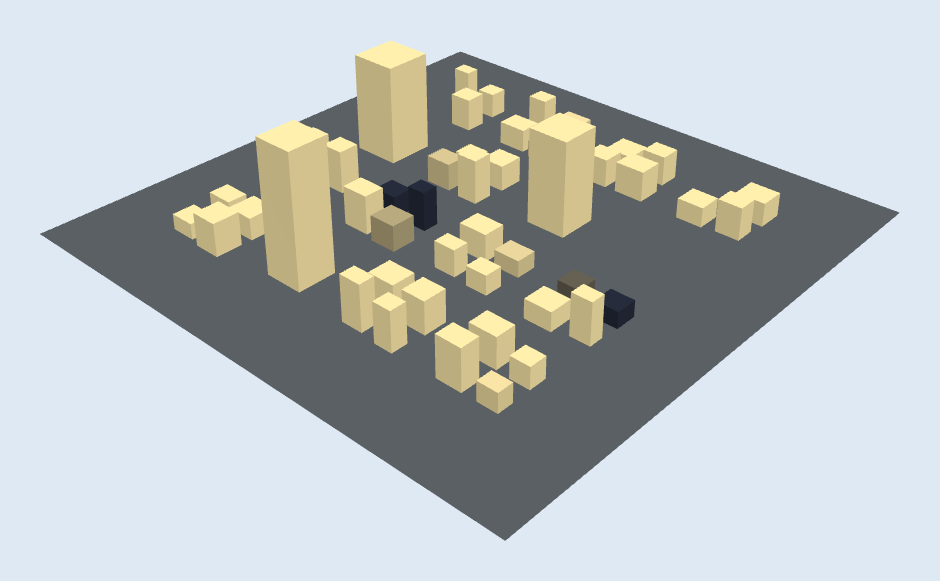

A grid of extruded buildings, lit ones in yellow and shaded ones dark -- Monty lays out the city; three.js casts a ray from every roof to the sun and darkens the buildings that are shaded.


In [8]:
from IPython.display import Image, display

display(Image(filename=str(REPO_ROOT / "docs" / "assets" / "examples" / "monty_three_city.png")))
print(
    "A grid of extruded buildings, lit ones in yellow and shaded ones dark -- "
    "Monty lays out the city; three.js casts a ray from every roof to the sun "
    "and darkens the buildings that are shaded."
)